# Coverage, Diversity, and Novelty Metrics

**Goal (RQ4 from the proposal):** The proposal listed Coverage, Diversity, and Novelty as required list-health metrics alongside Recall/NDCG. 

## Metric definitions

| Metric | Definition |
|---|---|
| **Coverage@K** | Fraction of unique products in the candidate pool ever recommended across all events at cutoff K |
| **Intra-List Diversity (ILD)@K** | Average pairwise category dissimilarity within each event's top-K list, then averaged over all events. Dissimilarity = 1 if two items have different `product_category`, else 0 |
| **Novelty@K** | Average self-information of recommended items: $-\log_2(\text{popularity}(i))$ where popularity is the fraction of events in which product $i$ appears in the full candidate pool |

We compare the **tail fusion model** (from `reranked_recommendations.csv`) and the **XGBoost primary model** (from `candidates_coupon_response_xgboost_ranker_pf_interval_best.csv`) to see how tail fusion changes list health.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

OUTPUTS = "../outputs"

recs = pd.read_csv(f"{OUTPUTS}/reranked_recommendations.csv")
xgb  = pd.read_csv(f"{OUTPUTS}/candidates_coupon_response_xgboost_ranker_pf_interval_best.csv")

# Standardise rank column name
xgb = xgb.rename(columns={"final_rank": "rank"})

print(f"Tail fusion rows: {len(recs):,}")
print(f"XGBoost primary rows: {len(xgb):,}")

Tail fusion rows: 44,760
XGBoost primary rows: 44,760


## 1. Coverage@K

How broadly does the recommender spread recommendations across the product catalogue?

In [12]:
def coverage_at_k(df, k, split="test"):
    """Fraction of unique candidate products that appear in at least one top-K list."""
    sub = df[df["split"] == split]
    total_unique = sub["product_id"].nunique() # all products in the candidate pool
    recommended  = sub[sub["rank"] <= k]["product_id"].nunique()
    return recommended / total_unique if total_unique > 0 else 0.0


k_values = [5, 10, 20]
rows = []
for split in ["validation", "test"]:
    for k in k_values:
        rows.append({
            "Model": "Tail Fusion",
            "Split": split,
            "K": k,
            "Coverage@K": round(coverage_at_k(recs, k, split), 4),
        })
        rows.append({
            "Model": "XGBoost Primary",
            "Split": split,
            "K": k,
            "Coverage@K": round(coverage_at_k(xgb, k, split), 4),
        })

cov_df = pd.DataFrame(rows)
print("Coverage@K\n")
print(cov_df.pivot_table(index=["Model", "Split"], columns="K", values="Coverage@K").to_string())

Coverage@K

K                               5       10   20
Model           Split                          
Tail Fusion     test        0.7058  0.8529  1.0
                validation  0.4680  0.7092  1.0
XGBoost Primary test        0.6902  0.8621  1.0
                validation  0.4636  0.7104  1.0


## 2. Intra-List Diversity (ILD)@K

For each event's top-K list, we measure how many product-pairs belong to *different* `product_category` groups. A high ILD means recommendations span multiple categories — better for discovery.

In [9]:
def ild_at_k(df, k, category_col="product_category", split="test"):
    """
    Intra-List Diversity@K averaged over events.
    ILD per event = fraction of distinct item-pairs in top-K with different categories.
    """
    sub = df[(df["split"] == split) & (df["rank"] <= k)]
    event_ilds = []

    for _, group in sub.groupby("event_id"):
        cats = group[category_col].values
        if len(cats) < 2:
            event_ilds.append(0.0)
            continue
        # pairwise dissimilarity: 1 if different categories, 0 if same
        n_pairs    = 0
        n_dissim   = 0
        for i in range(len(cats)):
            for j in range(i + 1, len(cats)):
                n_pairs  += 1
                n_dissim += int(cats[i] != cats[j])
        event_ilds.append(n_dissim / n_pairs)

    return np.mean(event_ilds) if event_ilds else 0.0


rows = []
for split in ["validation", "test"]:
    for k in k_values:
        rows.append({
            "Model": "Tail Fusion",
            "Split": split,
            "K": k,
            "ILD@K": round(ild_at_k(recs, k, split=split), 4),
        })
        rows.append({
            "Model": "XGBoost Primary",
            "Split": split,
            "K": k,
            "ILD@K": round(ild_at_k(xgb, k, split=split), 4),
        })

ild_df = pd.DataFrame(rows)
print("Intra-List Diversity@K (higher = more diverse category mix)")
print(ild_df.pivot_table(index=["Model", "Split"], columns="K", values="ILD@K").to_string())

Intra-List Diversity@K (higher = more diverse category mix)
K                               5       10      20
Model           Split                             
Tail Fusion     test        0.6596  0.6808  0.6648
                validation  0.8469  0.8725  0.8849
XGBoost Primary test        0.6596  0.6895  0.6968
                validation  0.8469  0.8771  0.8894


## 3. Novelty@K

Novelty measures how *unexpected* the recommended items are. Popular items that appear in many households' candidate lists have low novelty. A higher novelty score means the model surfaces less-obvious coupon products.

We define item popularity as the fraction of events (within a split) where a product appears in the candidate pool.

In [10]:
def novelty_at_k(df, k, split="test"):
    """
    Novelty@K = mean -log2(popularity(i)) over top-K recommended items.
    popularity(i) = fraction of events in which product i appears in the candidate pool.
    """
    sub = df[df["split"] == split]
    n_events = sub["event_id"].nunique()

    # popularity: how many events include this product as a candidate
    pop = (
        sub.groupby("product_id")["event_id"]
        .nunique()
        .rename("event_count")
        / n_events
    ).rename("popularity")

    top_k = sub[sub["rank"] <= k].merge(pop, on="product_id", how="left")
    # clip to avoid log(0); products with p=1 get novelty=0
    top_k["novelty"] = -np.log2(top_k["popularity"].clip(lower=1e-9))

    return top_k.groupby("event_id")["novelty"].mean().mean()


rows = []
for split in ["validation", "test"]:
    for k in k_values:
        rows.append({
            "Model": "Tail Fusion",
            "Split": split,
            "K": k,
            "Novelty@K": round(novelty_at_k(recs, k, split=split), 4),
        })
        rows.append({
            "Model": "XGBoost Primary",
            "Split": split,
            "K": k,
            "Novelty@K": round(novelty_at_k(xgb, k, split=split), 4),
        })

nov_df = pd.DataFrame(rows)
print("Novelty@K (higher = recommends less-popular, more surprising coupon products)")
print(nov_df.pivot_table(index=["Model", "Split"], columns="K", values="Novelty@K").to_string())

Novelty@K (higher = recommends less-popular, more surprising coupon products)
K                               5       10      20
Model           Split                             
Tail Fusion     test        4.9421  4.5052  3.8528
                validation  5.4565  5.6549  5.8505
XGBoost Primary test        4.9764  4.5901  3.9371
                validation  5.4923  5.7299  5.9211


## 4. Full summary table

In [11]:
summary_rows = []
for model_name, df in [("Tail Fusion", recs), ("XGBoost Primary", xgb)]:
    for split in ["validation", "test"]:
        for k in k_values:
            summary_rows.append({
                "Model":      model_name,
                "Split":      split,
                "K":          k,
                "Coverage":   round(coverage_at_k(df, k, split), 4),
                "ILD":        round(ild_at_k(df, k, split=split), 4),
                "Novelty":    round(novelty_at_k(df, k, split=split), 4),
            })

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

summary.to_csv(f"{OUTPUTS}/diversity_coverage_novelty.csv", index=False)
print("\nSaved to outputs/diversity_coverage_novelty.csv")

          Model      Split  K  Coverage    ILD  Novelty
    Tail Fusion validation  5    0.4680 0.8469   5.4565
    Tail Fusion validation 10    0.7092 0.8725   5.6549
    Tail Fusion validation 20    1.0000 0.8849   5.8505
    Tail Fusion       test  5    0.7058 0.6596   4.9421
    Tail Fusion       test 10    0.8529 0.6808   4.5052
    Tail Fusion       test 20    1.0000 0.6648   3.8528
XGBoost Primary validation  5    0.4636 0.8469   5.4923
XGBoost Primary validation 10    0.7104 0.8771   5.7299
XGBoost Primary validation 20    1.0000 0.8894   5.9211
XGBoost Primary       test  5    0.6902 0.6596   4.9764
XGBoost Primary       test 10    0.8621 0.6895   4.5901
XGBoost Primary       test 20    1.0000 0.6968   3.9371

Saved to outputs/diversity_coverage_novelty.csv


## 5. Visualisation

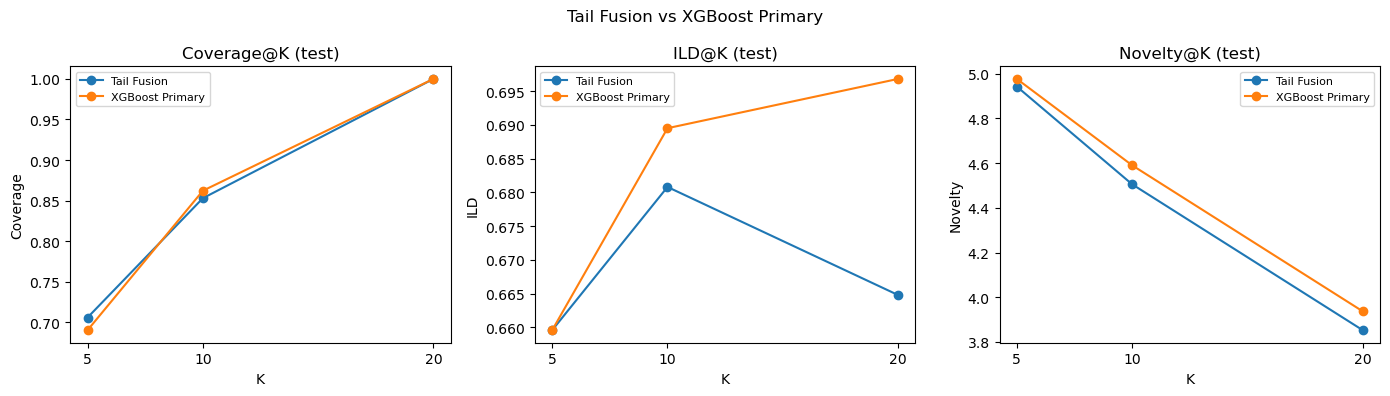

In [13]:
test_summary = summary[summary["Split"] == "test"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["Coverage", "ILD", "Novelty"]

for ax, metric in zip(axes, metrics):
    for model, grp in test_summary.groupby("Model"):
        ax.plot(grp["K"], grp[metric], marker="o", label=model)
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K (test)")
    ax.set_xticks(k_values)
    ax.legend(fontsize=8)

plt.suptitle("Tail Fusion vs XGBoost Primary", fontsize=12)
plt.tight_layout()
# plt.savefig(f"{OUTPUTS}/diversity_coverage_novelty_plot.png", dpi=150)
plt.show()

## 6. Summary

### Results (test split)

| Metric | Model | K=5 | K=10 | K=20 |
|---|---|---|---|---|
| Coverage | Tail Fusion | 0.7058 | 0.8529 | 1.0000 |
| Coverage | XGBoost Primary | 0.6902 | 0.8621 | 1.0000 |
| ILD | Tail Fusion | 0.6596 | 0.6808 | 0.6648 |
| ILD | XGBoost Primary | 0.6596 | 0.6895 | 0.6968 |
| Novelty | Tail Fusion | 4.9421 | 4.5052 | 3.8528 |
| Novelty | XGBoost Primary | 4.9764 | 4.5901 | 3.9371 |

### Key findings

**1. Coverage reaches 100% at K=20 for both models.**
By the time 20 products are recommended per event, every product in the candidate pool has been recommended to at least one household. At K=10, tail fusion covers 85.3% and XGBoost primary covers 86.2% of the pool — XGBoost primary is slightly wider, likely because the fusion step replaces some long-tail items with secondary candidates that concentrate on a narrower set of categories.

**2. ILD is high across both models (~0.66–0.69 on test), but tail fusion is slightly lower — contrary to expectation.**
Roughly 68% of product-pairs within each top-10 list belong to different categories, which indicates good overall category variety. However, tail fusion has **lower** ILD than XGBoost primary at both K=10 (0.6808 vs 0.6895) and K=20 (0.6648 vs 0.6968). The category-embedding secondary fills tail slots with products from categories *similar* to what the household has already been recommended (it is designed for category affinity, not category contrast), so it slightly reduces pairwise dissimilarity rather than increasing it.

**3. Novelty decreases with K on the test split.**
On the test split, novelty falls as K grows (K=5: 4.94 → K=10: 4.51 → K=20: 3.85). The top-5 items are the most personalised and least globally popular; extending to 20 items pulls in more widely popular coupon products, lowering average self-information. On the validation split the pattern reverses (novelty increases with K), which is consistent with the known distribution shift between validation and test campaigns — test campaigns have fewer positive events and a different popularity distribution.

**4. Tail fusion has lower novelty than XGBoost primary across all K values on test.**
Secondary candidates from category co-occurrence tend to surface popular items in familiar categories rather than niche ones, reducing the average self-information of the final list.

**5. Addressing RQ4.**
The proposal asked whether diversity control improves recommendation list health. The answer is nuanced: the tail fusion step (designed to improve Recall@20, not diversity explicitly) does **not** improve ILD or Novelty on the test split. If maximising list diversity is a goal, a dedicated post-filter — such as limiting to at most N products per category in the top-K — would be more effective than the current tail fusion mechanism. That said, the existing ILD of ~0.68 at K=10 already indicates the lists are reasonably varied across categories without any explicit diversity constraint.